In [1]:
import re
import json
import pandas as pd
from pathlib import Path
from collections import defaultdict, Counter

import chess
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from utils.score_responses import ResponseEvaluator
from utils.parsing import parse_fen
from utils.board import get_piece_name_at_location

In [2]:
PARENT_DIR = Path("model_outputs")
DATA_FOLDERS = [
    "llmchess-qwen25-7b-sft-dm22-400",
    "eval-qwen25-7b-sftdm22-drgrpo-dm11-400",
    "llmchess-qwen25-7b-sft-dm23-400",
    "eval-qwen25-7b-sftdm23-drgrpo-dm10-400",
    "llmchess-qwen25-7b-sft-dm24-400",
    "eval-qwen25-7b-sftdm24-drgrpo-dm10-400",
    "llmchess-qwen25-7b-sft-dm25-400",
    "eval-qwen25-7b-sftdm25-drgrpo-dm10-400",
    "llmchess-qwen25-7b-sft-dm26-400",
    "eval-qwen25-7b-sftdm26-drgrpo-dm10-400",
    "llmchess-qwen25-7b-sft-dm27-400",
    "eval-qwen25-7b-sftdm27-drgrpo-dm10-400",
    "llmchess-qwen25-7b-sft-dm28-400",
    "eval-qwen25-7b-sftdm28-drgrpo-dm10-400",
    "llmchess-qwen25-7b-sft-dm29-p1-400",
    "llmchess-qwen25-7b-sft-dm29-p4-400",
    "eval-qwen25-7b-sftdm29-p4-drgrpo-dm12-400",
    "llmchess-qwen25-7b-sft-dm30-400",
    "eval-qwen25-7b-sftdm30-drgrpo-dm10-400",
    "llmchess-qwen25-7b-sft-dm31-400",
    "eval-qwen25-7b-sftdm31-drgrpo-dm10-400",
    "llmchess-qwen25-7b-sft-dm32-400",
    "eval-qwen25-7b-sftdm32-drgrpo-dm12-400"
]

In [3]:
# Populate our board result dicts
board_result_dicts = {}
for data_folder in DATA_FOLDERS:
    folder_path = Path(PARENT_DIR) if data_folder is None else Path(PARENT_DIR) / data_folder
    for json_file in folder_path.glob("*.json*"):
        if json_file.suffix not in {".json", ".jsonl"}:
            continue
        key = f"{json_file.name} - [{data_folder}]"
        evaluator = ResponseEvaluator(str(folder_path), json_file.name)
        board_result_dicts[key] = evaluator.board_id_results

--------------------------------------------------
Results for model_outputs\llmchess-qwen25-7b-sft-dm22-400:
Filename: bestmove_eval_400_all_20250808-221920.json
Count: Sample Questions: 400
Count: Total Generations: 400
Count: Legal Generations: 394
Total: Cumulative Score: 90
Error: Illegal Move: 6
Error: Parsing: 0
Error: Other: 0
Avg. Score - All: 0.225
Avg. Score - Legal: 0.22842639593908629
Error Rate: 0.015
--------------------------------------------------

--------------------------------------------------
Results for model_outputs\llmchess-qwen25-7b-sft-dm22-400:
Filename: legalmoves_eval_400_all_20250808-221920.json
Count: Sample Questions: 400
Count: Total Generations: 400
Count: Legal Generations: 372
Total: Cumulative Score: 98.29018848798266
Error: Illegal Move: 0
Error: Parsing: 28
Error: Other: 0
Avg. Score - All: 0.24572547121995666
Avg. Score - Legal: 0.26422093679565234
Error Rate: 0.07
--------------------------------------------------

---------------------------

In [4]:
def bar_by(df, x_col, y_col, *, n_bins=10, title=None):
    """
    Dual‑axis bar plot:
      • left  y‑axis: mean(y_col) per bucket (blue)
      • right y‑axis: count per bucket (orange)

    Buckets: unique values if ≤10 else `n_bins` equal‑width numeric buckets.
    """
    x, y = df[x_col], df[y_col]

    # ── Bucket assignment ────────────────────────────────────────────
    if pd.api.types.is_numeric_dtype(x):
        if x.nunique() <= 10:
            labels = sorted(x.unique())
            grp_idx = x
        else:
            bins   = np.linspace(x.min(), x.max(), n_bins + 1)
            labels = [f"{int(bins[i])}–{int(bins[i+1]-1)}" for i in range(n_bins)]
            grp_idx = pd.cut(x, bins=bins, labels=labels, include_lowest=True)
    else:  # categorical x
        labels  = sorted(x.astype(str).unique())
        grp_idx = x.astype(str)

    # ── Aggregation ──────────────────────────────────────────────────
    mean_vals  = y.groupby(grp_idx, observed=True).mean().reindex(labels)
    count_vals = y.groupby(grp_idx, observed=True).count().reindex(labels).fillna(0)

    # ── Plot ─────────────────────────────────────────────────────────
    xpos, width = np.arange(len(labels)), 0.35
    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax2 = ax1.twinx()

    bars_mean  = ax1.bar(xpos - width/2, mean_vals.values, width, color="#1f77b4")
    bars_count = ax2.bar(xpos + width/2, count_vals.values, width,
                         color="orange", label="# samples")

    ax1.set_xlabel(x_col)
    ax1.set_ylabel(f"mean({y_col})")
    ax2.set_ylabel("count")
    ax1.set_xticks(xpos)
    ax1.set_xticklabels(labels, rotation=45, ha="right")
    ax1.set_title(title or f"{y_col} by {x_col}")

    # Annotate bars
    for rect in bars_mean:
        ax1.text(rect.get_x() + rect.get_width()/2,
                 rect.get_height() + 0.01,
                 f"{rect.get_height():.2f}",
                 ha="center", va="bottom", fontsize=8)
    for rect in bars_count:
        ax2.text(rect.get_x() + rect.get_width()/2,
                 rect.get_height() + 0.01,
                 f"{int(rect.get_height())}",
                 ha="center", va="bottom", fontsize=8)

    ax1.legend([bars_count], ["# samples"], loc="upper right")
    fig.tight_layout()
    plt.show()

# Predict Move   
---

In [ ]:
plot_move_stats = True

# Trivial Move Types
move_type = {
    "Standard Activate Knight": ["b1c3", "g1f3", "b8c6", "g8f6"],
    "Move Edge Pawn": ["a2a4", "a2a3", "h2h4", "h2h3", "a7a5", "a7a6", "h7h5", "h7h6"],
    "Trivial King/Rook": ["a1b1", "b1a1", "a8b8", "b8a8", "h1g1", "g1h1", "h8g8", "g8h8"]
}

if plot_move_stats:
    for key, results in board_result_dicts.items():
        if not key.startswith("predictmove"):
            continue

        rows = []
        for board_id, data in results.items():
            fen = data['info']["board"]
            parsed = parse_fen(fen)
            fullmove = parsed["fullmove_number"]

            # Build a python-chess board with proper turn side
            try:
                board = chess.Board(fen)
            except Exception:
                board = None

            for score_raw, move in data.get("score_answers", []):
                try:         # numeric score or NaN for '<ERROR>'
                    score = float(score_raw)
                except (ValueError, TypeError):
                    score = np.nan

                piece_name = "na"  # aggregate by piece only, not color
                if board is not None and isinstance(move, str):
                    # Moves are expected as UCI (e.g., 'e2e4', 'e7e8q').
                    try:
                        uci = move.strip().lower()
                        m = chess.Move.from_uci(uci)
                        if m in board.legal_moves:
                            p = board.piece_at(m.from_square)
                            if p is not None:
                                piece_map = {
                                    chess.PAWN: "pawn",
                                    chess.KNIGHT: "knight",
                                    chess.BISHOP: "bishop",
                                    chess.ROOK: "rook",
                                    chess.QUEEN: "queen",
                                    chess.KING: "king",
                                }
                                piece_name = piece_map.get(p.piece_type, "unknown")
                        # Do not push the move; we analyze per-row and keep board at FEN state
                    except Exception:
                        piece_name = "na"

                rows.append({
                    "board_id":   board_id,
                    "fullmove":   fullmove,
                    "move":       move,
                    "score":      score,
                    "piece_type": piece_name
                })

        if not rows:
            continue

        df = pd.DataFrame(rows)

        # ── 1) Histogram (mean score vs fullmove buckets) ────────────
        clean_df = df.dropna(subset=["score"])
        # if not clean_df.empty:
        #     df["fullmove_bucket"] = (df["fullmove"] // 10) * 10
        #     bar_by(
        #         df.dropna(subset=["score"]),
        #         x_col="fullmove_bucket",
        #         y_col="score",
        #         title=f"{key}: Avg. Score vs Fullmove Count"
        #     )

        # ── 2) Move statistics ───────────────────────────────────────
        print(f"\n{key} — Top 10 moves [total legal: {len(clean_df)}]:")
        move_counts = clean_df["move"].value_counts().head(10)
        move_stats  = (
            clean_df.groupby("move")["score"]
                .agg(["mean", "std"])
                .reindex(move_counts.index)
        )
        for mv in move_counts.index:
            cnt  = move_counts[mv]
            mean = move_stats.loc[mv, "mean"]
            std  = move_stats.loc[mv, "std"]
            mean_str = f"{mean:.3f}" if not np.isnan(mean) else "—"
            std_str  = f"{std:.3f}"  if not np.isnan(std)  else "—"
            print(f"{mv:<8} count={cnt:>5} mean={mean_str:>7} std={std_str:>7}")

        # ── 3) Trivial Move Type Counts ──────────────────────────────
        total_moves = len(clean_df)
        total_trivial_moves = 0
        print(f"\nTrivial Move Type Counts:")
        for mt_key, mt_moves in move_type.items():
            mt_count = clean_df["move"].isin(mt_moves).sum()
            percent = (mt_count / total_moves * 100) if total_moves > 0 else 0.0
            total_trivial_moves += mt_count
            print(f"   {mt_key:<25}: {mt_count:>5} [{percent:>5.1f}%]")
        
        print(f"{'Total Trivial Moves':<28}: {total_trivial_moves:>5} [{(total_trivial_moves/total_moves)*100:>5.1f}%]")
        
        
        # -- 4) Count and score by piece type --------------------------
        # Print out the different piece types and the number associated
        # as well as the mean score (to 3 decimals)
        piece_df = clean_df.copy()
        piece_df["piece_type"] = piece_df["piece_type"].fillna("na")
        piece_stats = piece_df.groupby("piece_type")["score"].agg(["count", "mean"]).sort_values("count", ascending=False)
        print("\nPiece Type Counts and Mean Scores:")
        for idx, row in piece_stats.iterrows():
            mean_val = row["mean"]
            mean_str = f"{mean_val:.3f}" if not np.isnan(mean_val) else "—"
            print(f"   {idx:<15} count={int(row['count']):>6} mean={mean_str:>7}")
        print("-" * 60)


predictmove_eval_400_all_20250808-221920.json - [llmchess-qwen25-7b-sft-dm22-400] — Top 10 moves [total legal: 135]:
b8c6     count=   17 mean=  0.710 std=  0.266
b1c3     count=    7 mean=  0.654 std=  0.281
d7d5     count=    6 mean=  0.740 std=  0.214
g8f6     count=    5 mean=  0.707 std=  0.334
e8g8     count=    5 mean=  0.724 std=  0.257
e1g1     count=    5 mean=  0.904 std=  0.081
g1h1     count=    3 mean=  0.687 std=  0.103
d1e2     count=    3 mean=  0.721 std=  0.014
g1f3     count=    3 mean=  0.838 std=  0.092
d1d3     count=    3 mean=  0.523 std=  0.445

Trivial Move Type Counts:
   Standard Activate Knight :    32 [ 23.7%]
   Move Edge Pawn           :     0 [  0.0%]
   Trivial Rook             :     6 [  4.4%]
Total Trivial Moves         :    38 [ 28.1%]

Piece Type Counts and Mean Scores:
   knight          count=    40 mean=  0.670
   queen           count=    26 mean=  0.551
   king            count=    22 mean=  0.622
   rook            count=    21 mean=  0.446

C:\Users\lucas\AppData\Local\Temp\ipykernel_8952\3480828441.py:57: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


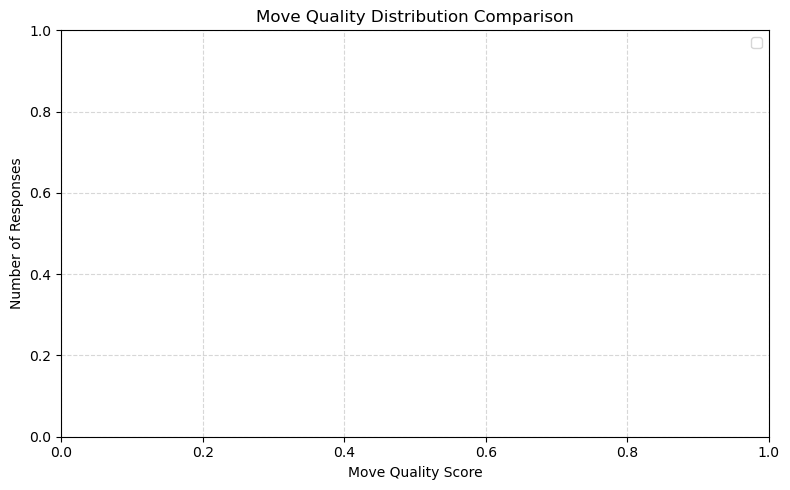

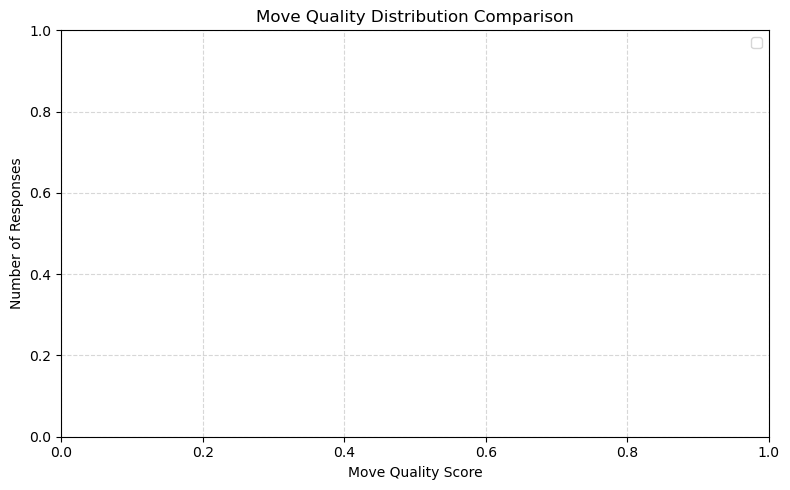

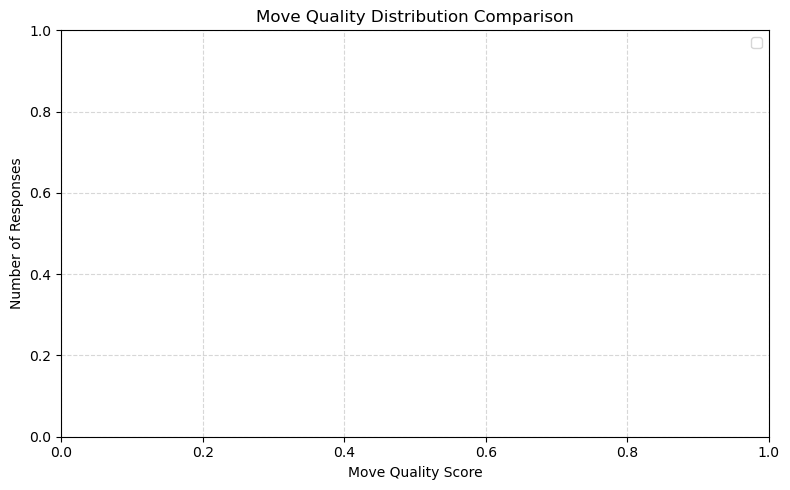

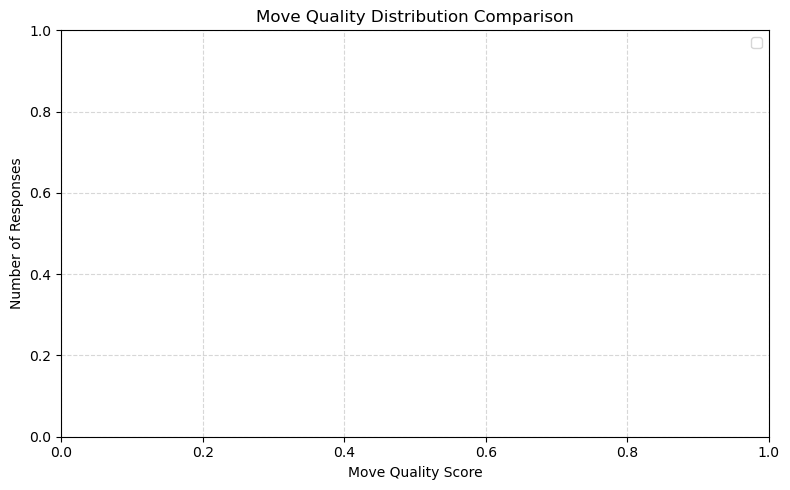

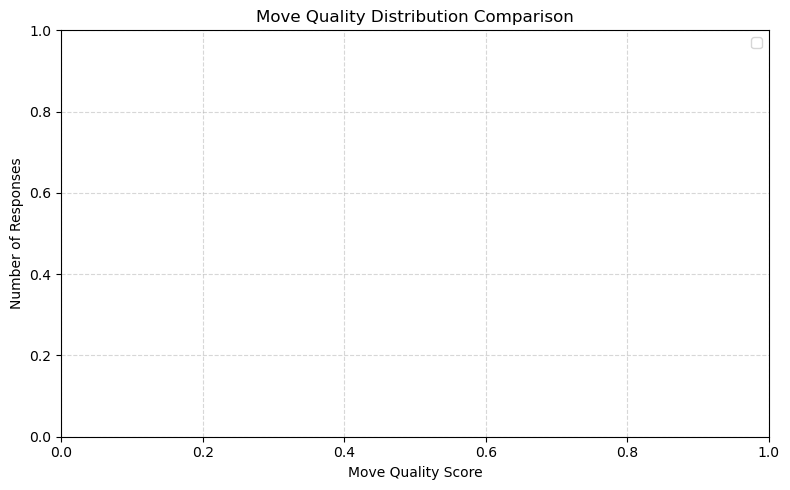

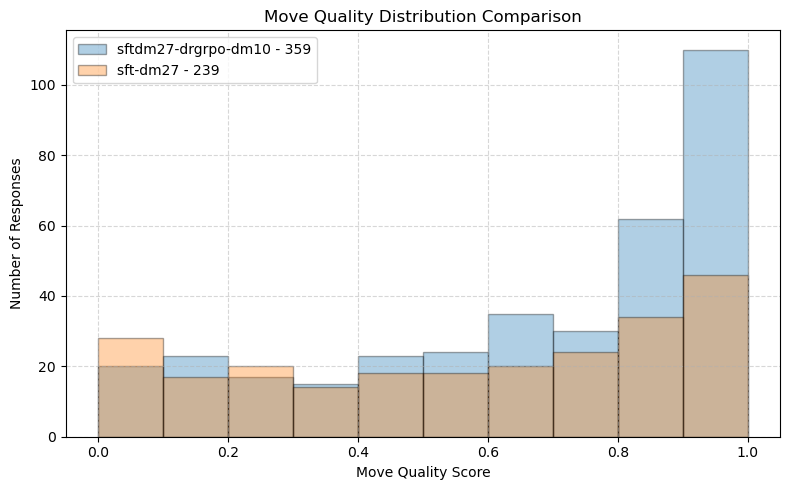

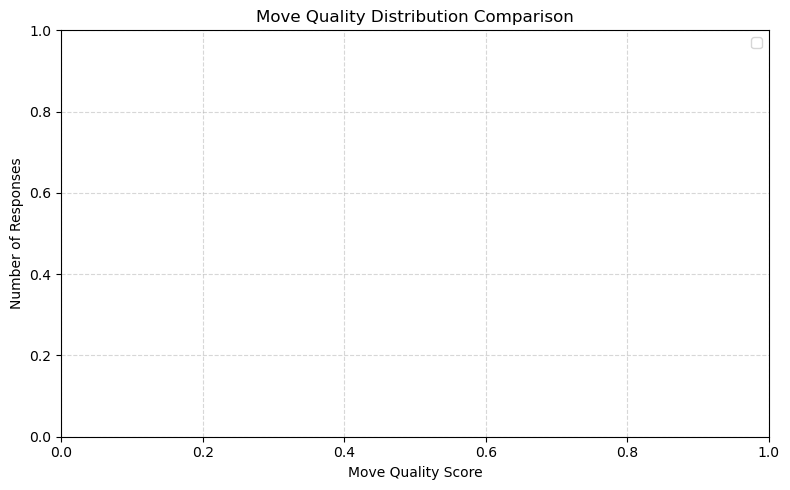

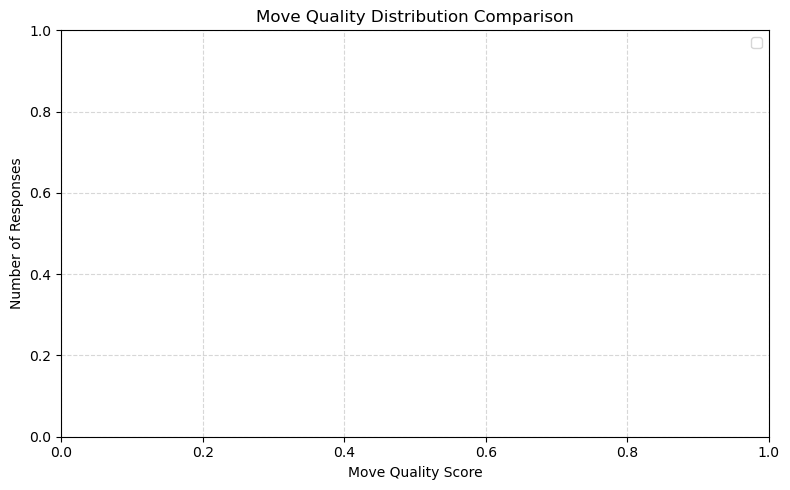

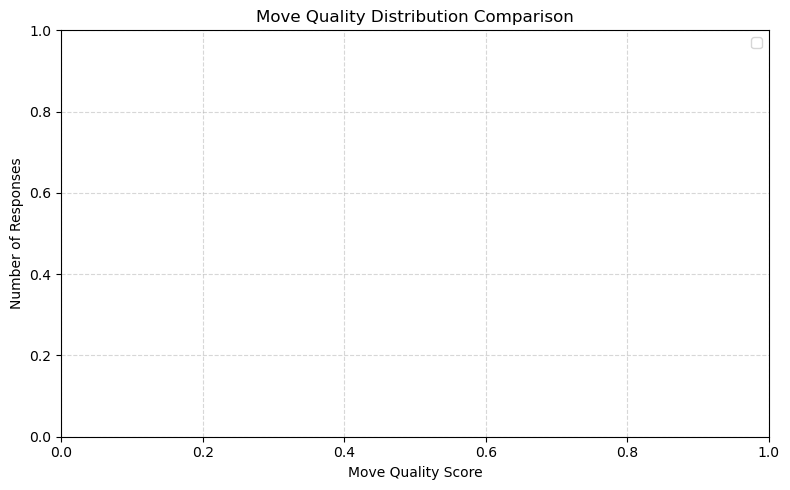

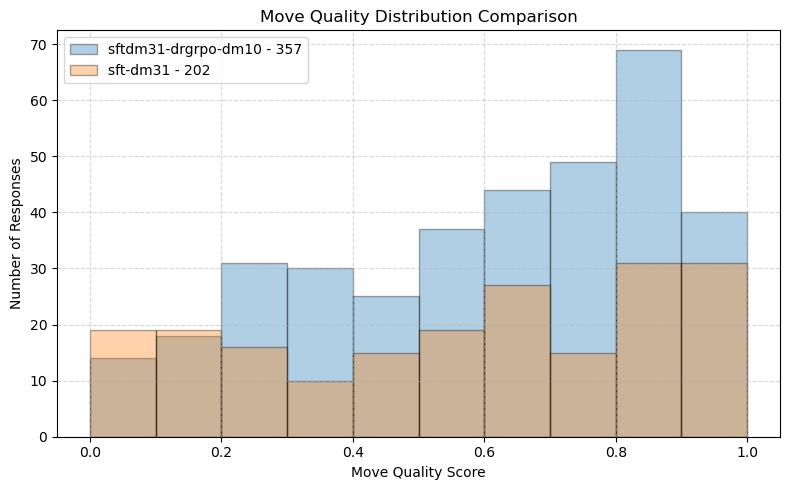

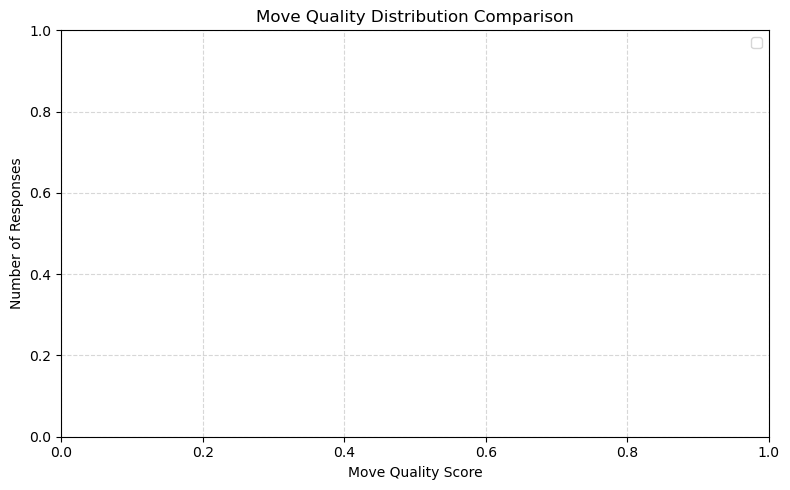

In [6]:
# Set this to True to show smoothed line (KDE) plots, or False for bar charts
show_kde = False  # <-- Change to True for smoothed line charts

def get_short_name(folder):
    name = re.sub(r"^llmchess-qwen25-7b-", "", folder)
    name = re.sub(r"^eval-qwen25-7b-", "", name)
    name = re.sub(r"-400$", "", name)
    return name

def get_scores_for_folder(folder):
    scores = []
    for key, results in board_result_dicts.items():
        if folder in key and key.startswith("predictmove"):
            for board_id, data in results.items():
                for score_raw, _ in data.get("score_answers", []):
                    try:
                        score = float(score_raw)
                    except (ValueError, TypeError):
                        score = np.nan
                    if not np.isnan(score):
                        scores.append(score)
    return scores

FOLDER_COMBINATIONS = [
    ["eval-qwen25-7b-sftdm22-drgrpo-dm11-400", "llmchess-qwen25-7b-sft-dm22-400"],
    ["eval-qwen25-7b-sftdm23-drgrpo-dm10-400", "llmchess-qwen25-7b-sft-dm23-400"],
    ["eval-qwen25-7b-sftdm24-drgrpo-dm10-400", "llmchess-qwen25-7b-sft-dm24-400"],
    ["eval-qwen25-7b-sftdm25-drgrpo-dm10-400", "llmchess-qwen25-7b-sft-dm25-400"],
    ["eval-qwen25-7b-sftdm26-drgrpo-dm10-400", "llmchess-qwen25-7b-sft-dm26-400"],
    ["eval-qwen25-7b-sftdm27-drgrpo-dm10-400", "llmchess-qwen25-7b-sft-dm27-400"],
    ["eval-qwen25-7b-sftdm28-drgrpo-dm10-400", "llmchess-qwen25-7b-sft-dm28-400"],
    ["eval-qwen25-7b-sftdm29-p4-drgrpo-dm12-400", "llmchess-qwen25-7b-sft-dm29-p4-400", "llmchess-qwen25-7b-sft-dm29-p1-400"],
    ["eval-qwen25-7b-sftdm30-drgrpo-dm10-400", "llmchess-qwen25-7b-sft-dm30-400"],
    ["eval-qwen25-7b-sftdm31-drgrpo-dm10-400", "llmchess-qwen25-7b-sft-dm31-400"],
    ["eval-qwen25-7b-sftdm32-drgrpo-dm12-400", "llmchess-qwen25-7b-sft-dm32-400"],
]

bin_edges = np.arange(0, 1.0001, 0.1)

for combo in FOLDER_COMBINATIONS:
    plt.figure(figsize=(8, 5))
    for folder in combo:
        scores = get_scores_for_folder(folder)
        n = len(scores)
        if n == 0:
            continue
        short = get_short_name(folder)
        if show_kde:
            # KDE plot (smoothed line)
            if n > 1:  # KDE needs at least 2 points
                sns.kdeplot(scores, bw_adjust=0.5, clip=(0,1), label=f"{short} - {n}", fill=True, alpha=0.25)
        else:
            plt.hist(scores, bins=bin_edges, alpha=0.35, label=f"{short} - {n}", edgecolor='black', density=False)
    plt.xlabel("Move Quality Score")
    plt.ylabel("Density" if show_kde else "Number of Responses")
    plt.title("Move Quality Distribution Comparison")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# Legal Moves   
---

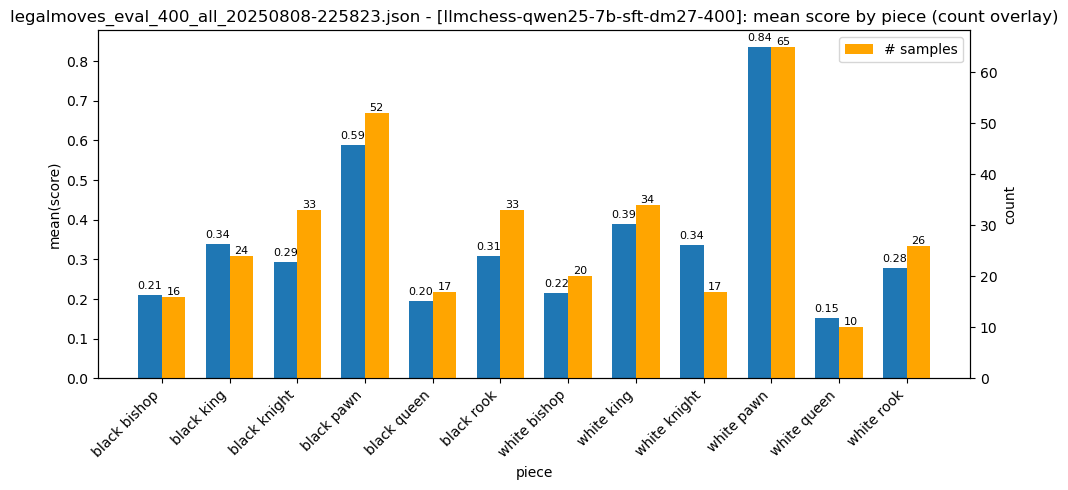

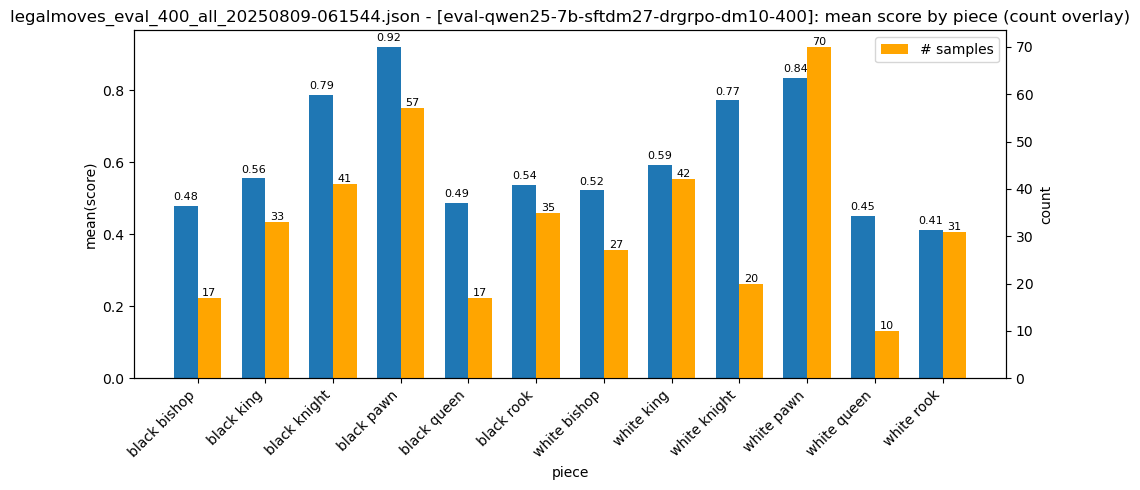

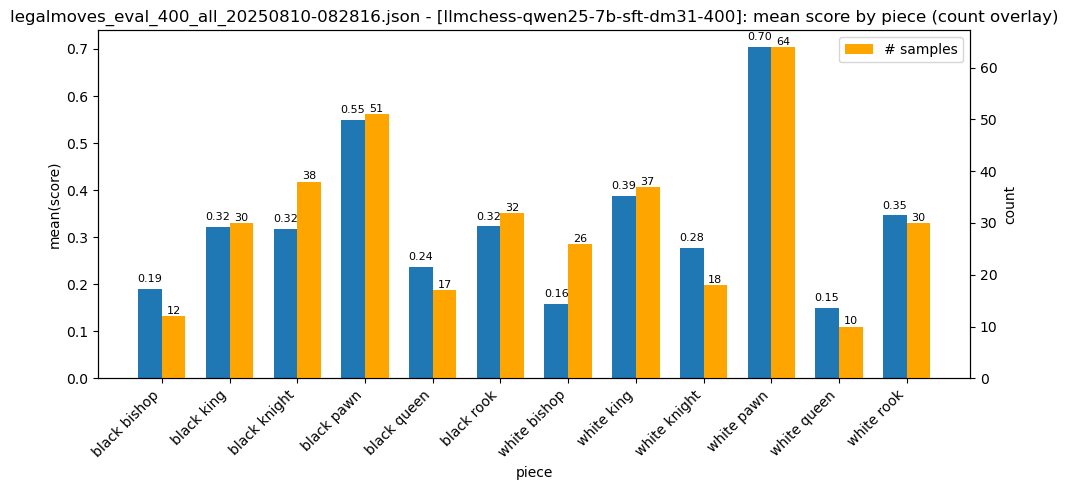

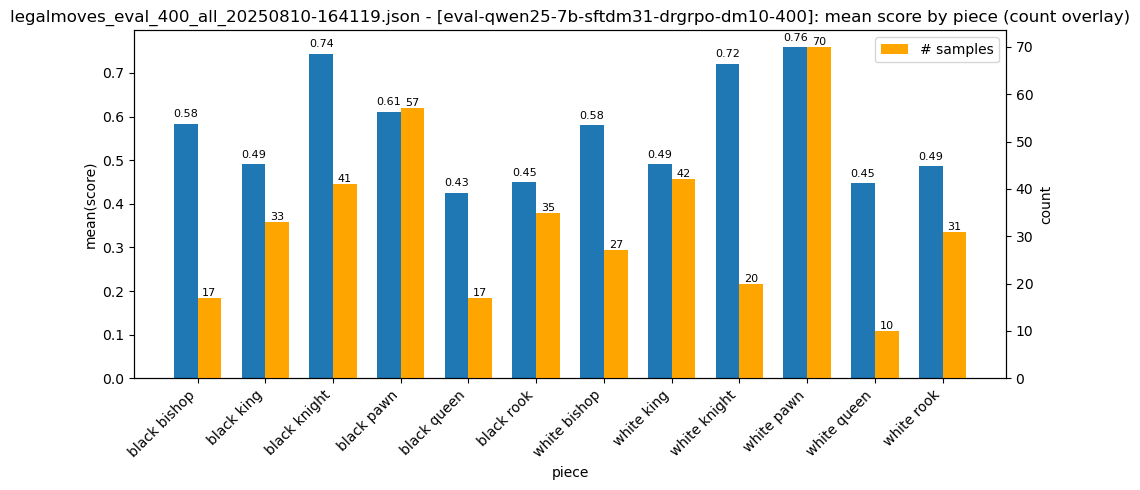

In [7]:
for key, results in board_result_dicts.items():
    if not key.startswith("legalmoves"):
        continue

    rows = []
    for board_id, data in results.items():
        piece = data["info"]["task_data"][0]   # e.g. 'black bishop'
        for score_raw, _ in data.get("score_answers", []):
            try:
                score = float(score_raw)      # 0‥1 numeric
            except (ValueError, TypeError):
                score = pd.NA                 # '<ERROR>' → NA
            rows.append({"piece": piece, "score": score})

    df = pd.DataFrame(rows).dropna(subset=["score"]).astype({"score": float})
    if df.empty:
        print(f"{key}: no valid scores")
        continue

    bar_by(
        df,
        x_col="piece",
        y_col="score",
        title=f"{key}: mean score by piece (count overlay)"
    )

# Best Move   
---

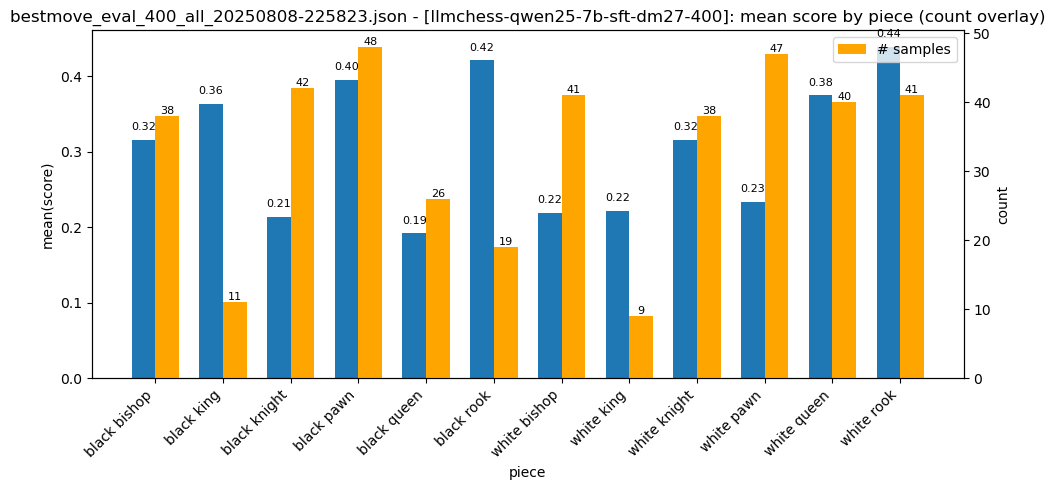

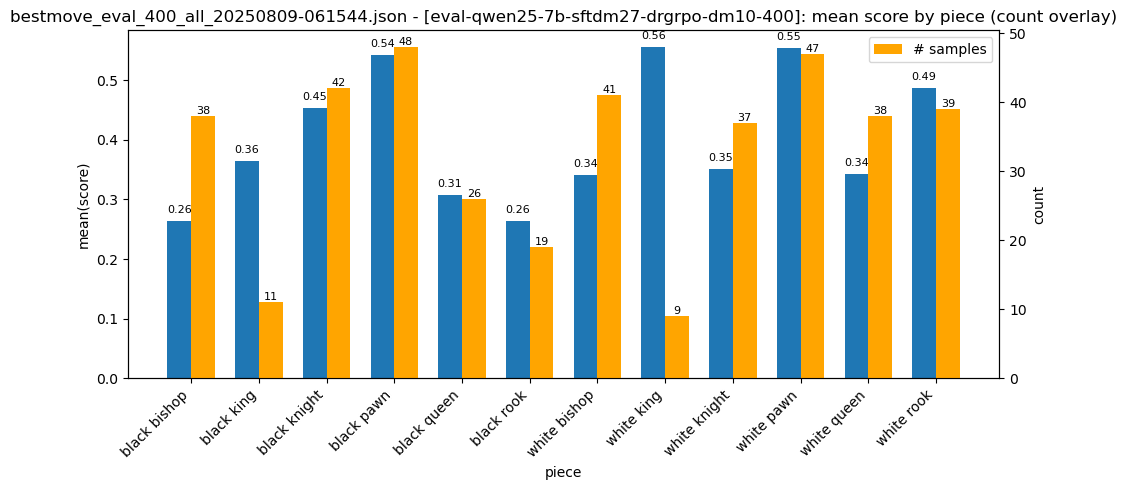

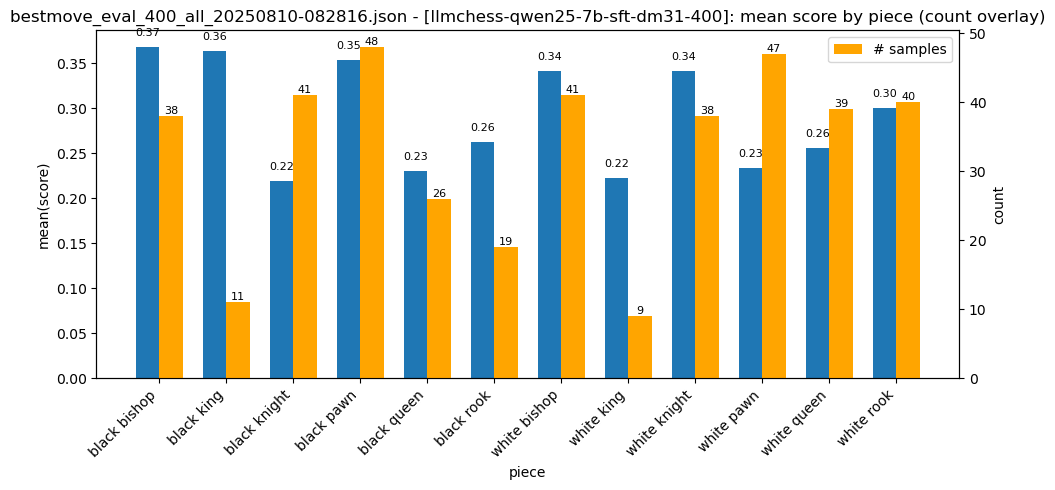

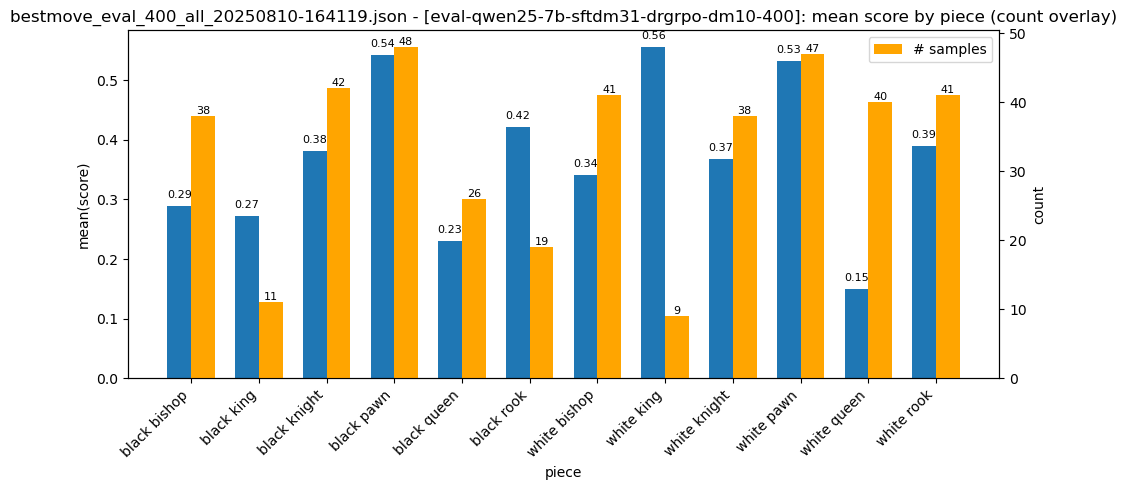

In [11]:
for key, results in board_result_dicts.items():
    if not key.startswith("bestmove"):
        continue

    rows = []
    for board_id, data in results.items():
        fen       = data["info"]["board"]
        fullmove  = parse_fen(fen)["fullmove_number"]
        # correct answer square = first 2 chars of SAN‑less move string
        src_sq    = data["info"]["answer"]["answer"][:2].lower()

        piece = get_piece_name_at_location(fen, src_sq)  # e.g. 'white knight'

        for score_raw, _ in data.get("score_answers", []):
            try:
                score = float(score_raw)
            except (ValueError, TypeError):
                score = np.nan
            rows.append({
                "board_id": board_id,
                "fullmove": fullmove,
                "piece":    piece,
                "score":    score,
            })

    df = pd.DataFrame(rows).dropna(subset=["score"]).astype({"score": float})
    if df.empty:
        print(f"{key}: no valid scores.")
        continue

    # ─── 1) Score vs full‑move count buckets ────────────────────
    df["fullmove_bucket"] = (df["fullmove"] // 10) * 10
    # bar_by(
    #     df.dropna(subset=["score"]),
    #     x_col="fullmove_bucket",
    #     y_col="score",
    #     title=f"{key}: Avg. Score vs Fullmove Count"
    # )

    # ─── 2) Score vs piece type ─────────────────────────────────
    bar_by(
        df,
        x_col="piece",
        y_col="score",
        title=f"{key}: mean score by piece (count overlay)"
    )

# Worst Move   
---

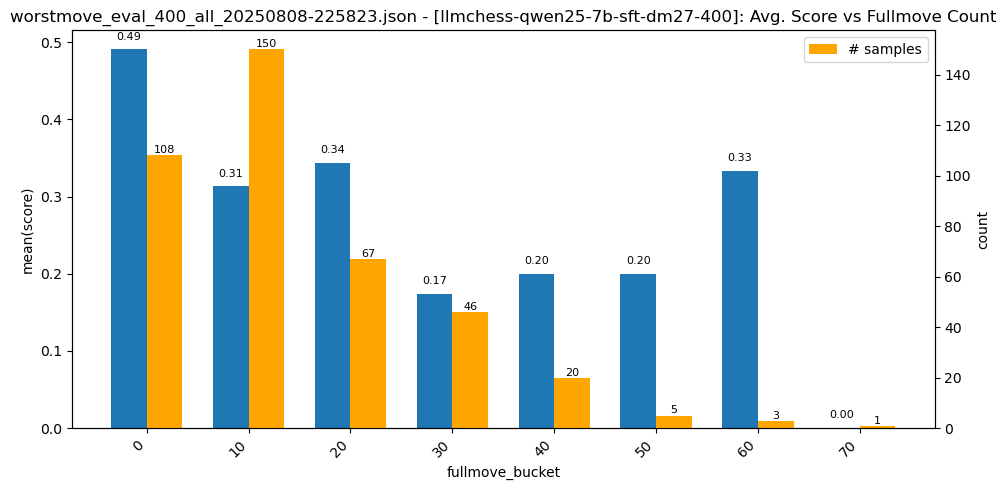

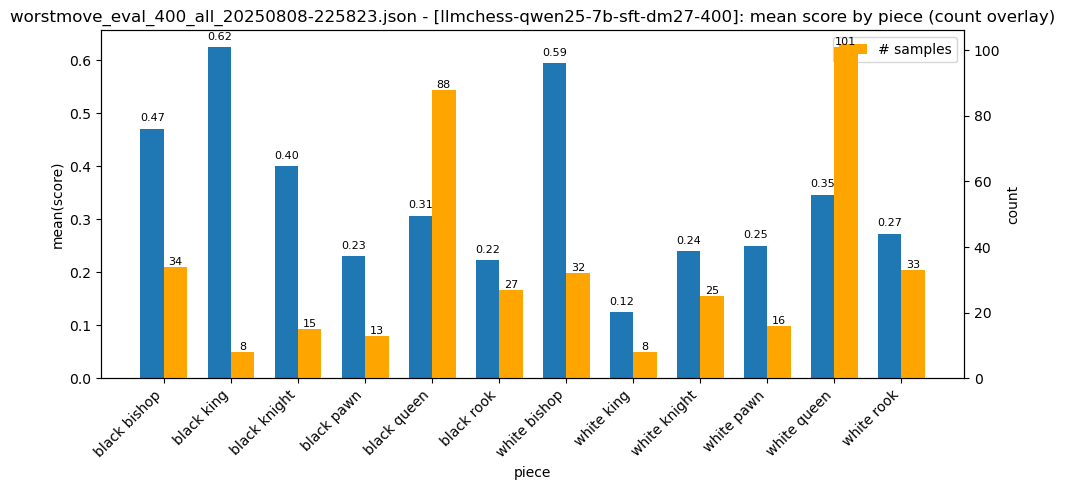

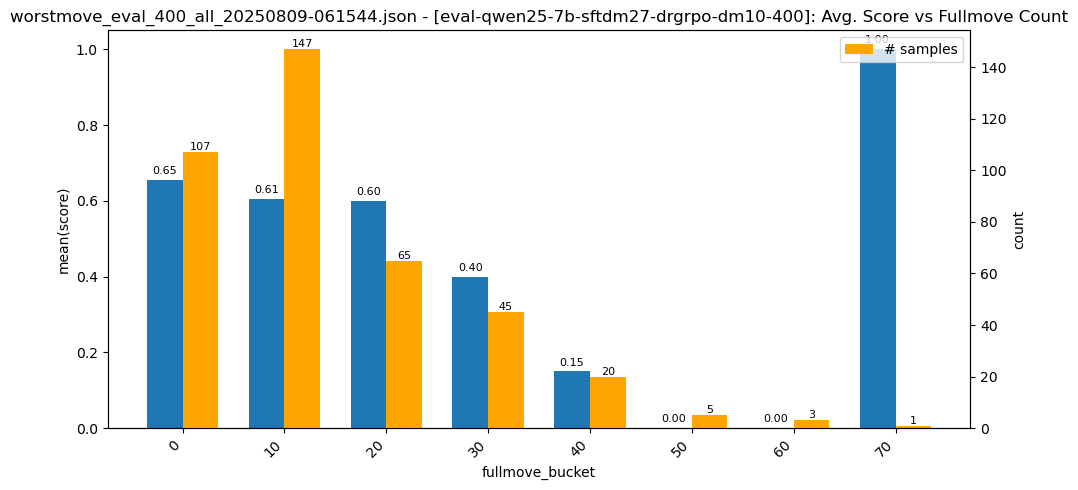

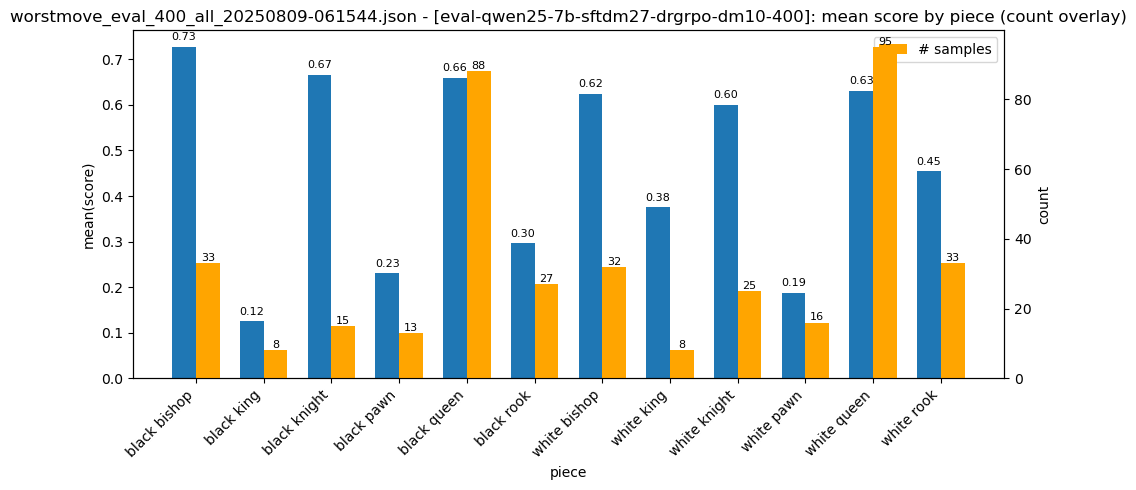

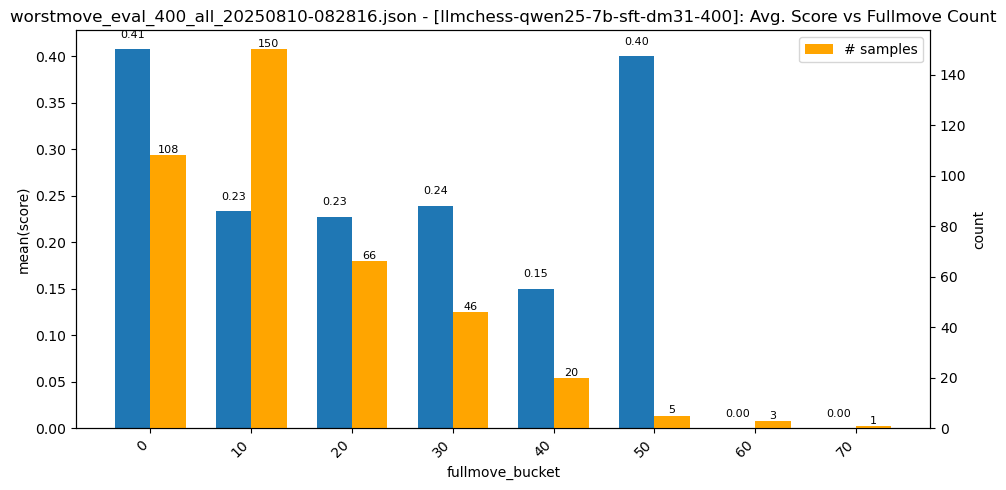

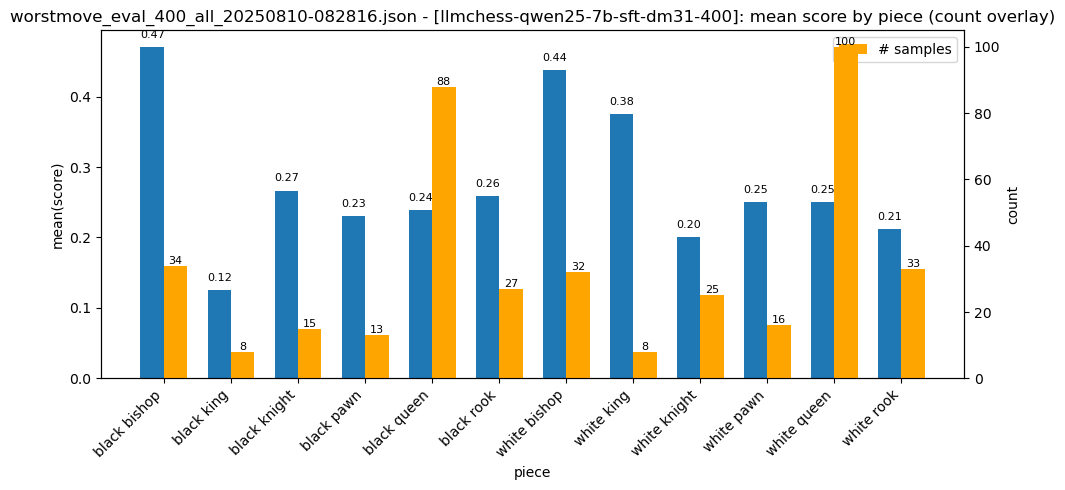

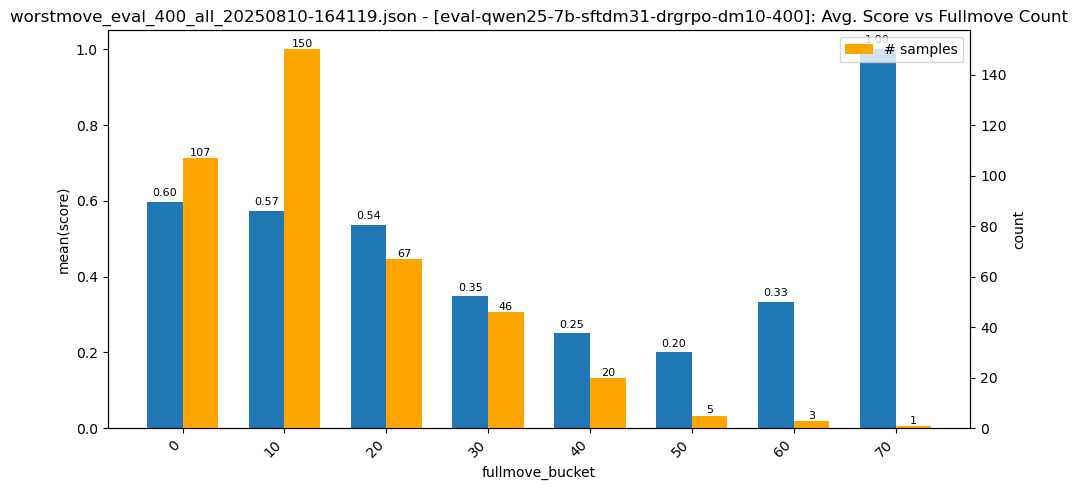

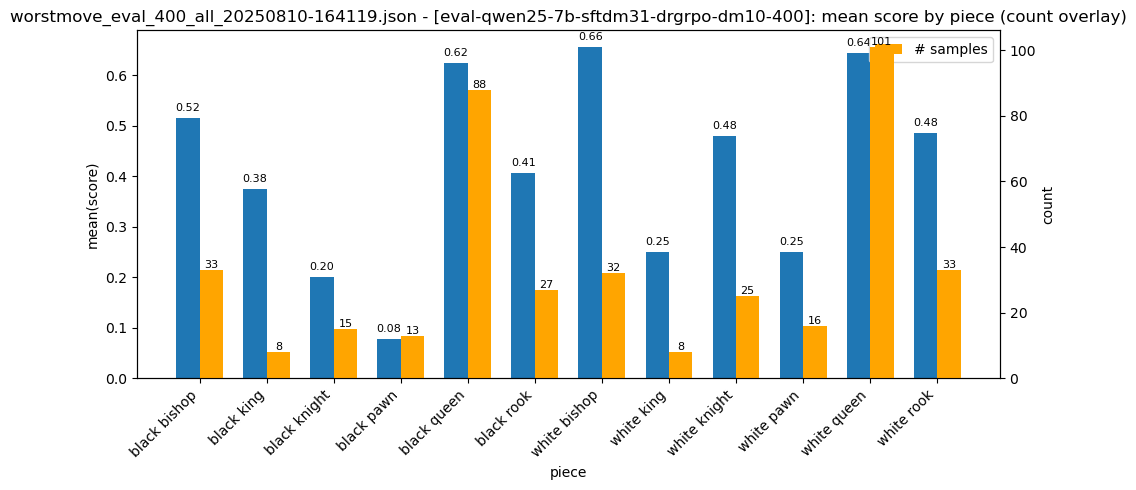

In [9]:
for key, results in board_result_dicts.items():
    if not key.startswith("worstmove"):
        continue

    rows = []
    for board_id, data in results.items():
        fen       = data["info"]["board"]
        fullmove  = parse_fen(fen)["fullmove_number"]
        # correct answer square = first 2 chars of SAN‑less move string
        src_sq    = data["info"]["answer"]["answer"][:2].lower()

        piece = get_piece_name_at_location(fen, src_sq)  # e.g. 'white knight'

        for score_raw, _ in data.get("score_answers", []):
            try:
                score = float(score_raw)
            except (ValueError, TypeError):
                score = np.nan
            rows.append({
                "board_id": board_id,
                "fullmove": fullmove,
                "piece":    piece,
                "score":    score,
            })

    df = pd.DataFrame(rows).dropna(subset=["score"]).astype({"score": float})
    if df.empty:
        print(f"{key}: no valid scores.")
        continue

    # ─── 1) Score vs full‑move count buckets ────────────────────
    df["fullmove_bucket"] = (df["fullmove"] // 10) * 10
    bar_by(
        df.dropna(subset=["score"]),
        x_col="fullmove_bucket",
        y_col="score",
        title=f"{key}: Avg. Score vs Fullmove Count"
    )

    # ─── 2) Score vs piece type ─────────────────────────────────
    bar_by(
        df,
        x_col="piece",
        y_col="score",
        title=f"{key}: mean score by piece (count overlay)"
    )